# Key recovery en AES-128 reducido: 2 y 3 rondas

Se comparan dos ataques con pares reales de textos claros. No se generan estados intermedios sinteticos.

La caracteristica base se lee de `find_characteristics/aes_128_3round_characteristic.json`.

In [ ]:
from pathlib import Path
import json
import math
import random
import sys

import matplotlib.pyplot as plt
import pandas as pd


def add_repo_root_to_path():
    current = Path.cwd().resolve()
    for path in [current, *current.parents]:
        if (path / "cryptosystems").is_dir() and (path / "find_characteristics").is_dir():
            if str(path) not in sys.path:
                sys.path.insert(0, str(path))
            return path
    raise RuntimeError("No se encontro la raiz del repositorio")


ROOT = add_repo_root_to_path()
from cryptosystems.aes import INV_S_BOX
from cryptosystems.reduced_aes import ReducedAES

pd.set_option("display.max_columns", None)
print(f"Repo root: {ROOT}")

Repo root: C:\Users\juanc\github\Differential-Cryptanalysis-


## Caracteristica de referencia

$$\mathtt{B30000000058000000004500000000F7}$$
$$\longrightarrow\mathtt{01000000000000000000000000000000}$$
$$\longrightarrow\mathtt{3E1F1F21000000000000000000000000}$$
$$\longrightarrow\mathtt{D10000000000009E0000A30000A30000}.$$

La probabilidad completa es $2^{-54}$.

In [ ]:
path = ROOT / "find_characteristics" / "aes_128_3round_characteristic.json"
characteristic = json.loads(path.read_text(encoding="utf-8"))
round_records = characteristic["rounds"]

pd.DataFrame([
    {
        "ronda": item["round"],
        "entrada": item["input_difference"],
        "salida": item["output_difference"],
        "S-boxes activas": item["active_sboxes"],
        "probabilidad": item["probability"],
        "peso": item["weight"],
    }
    for item in round_records
])

,ronda,entrada,salida,S-boxes activas,probabilidad,peso
0,1,0xB30000000058000000004500000000F7,0x01000000000000000000000000000000,4,5.960464e-08,24.0
1,2,0x01000000000000000000000000000000,0x3E1F1F21000000000000000000000000,1,1.562500e-02,6.0
2,3,0x3E1F1F21000000000000000000000000,0xD10000000000009E0000A30000A30000,4,5.960464e-08,24.0


## Funciones del ataque

Para un candidato $k$ se calcula

$$\widehat U_{\pi(j)}(k)=S^{-1}(C_j\oplus k),$$

y se cuenta cuando la diferencia coincide con $\Delta U_{\pi(j)}$.

In [ ]:
MASTER_KEY_HEX = "000102030405060708090A0B0C0D0E0F"
BLOCK_BITS = 128
KEY_BITS = 128
SEED = 2026


def prepare_positions(cipher, delta_u):
    delta_bytes = cipher._int_to_state(delta_u)
    origins = list(range(cipher.block_bytes))
    cipher._shift_rows(origins)
    active = [position for position, origin in enumerate(origins) if delta_bytes[origin] != 0]
    return delta_bytes, origins, active


def generate_ciphertext_pairs(cipher, round_keys, delta_p, n_pairs, seed):
    rng = random.Random(seed)
    pairs = []
    for _ in range(n_pairs):
        p = rng.randrange(0, 1 << cipher.block_bits)
        c = cipher.encrypt_block(p, round_keys)
        c_prime = cipher.encrypt_block(p ^ delta_p, round_keys)
        pairs.append((cipher._int_to_state(c), cipher._int_to_state(c_prime)))
    return pairs


def rank_key_bytes(cipher, pairs, delta_u):
    delta_bytes, origins, active = prepare_positions(cipher, delta_u)
    rankings = {}
    for position in active:
        target = delta_bytes[origins[position]]
        rows = []
        for key_guess in range(256):
            score = 0
            for c, c_prime in pairs:
                u = INV_S_BOX[c[position] ^ key_guess]
                u_prime = INV_S_BOX[c_prime[position] ^ key_guess]
                score += (u ^ u_prime) == target
            rows.append({"candidate_int": key_guess, "candidato": f"0x{key_guess:02X}", "score": score})
        rankings[position] = pd.DataFrame(rows).sort_values(
            ["score", "candidate_int"], ascending=[False, True]
        ).reset_index(drop=True)
    return rankings, delta_bytes, origins, active


def summarize_rankings(cipher, last_key, rankings):
    true_bytes = cipher._int_to_state(last_key)
    rows = []
    for position, df in rankings.items():
        true_byte = true_bytes[position]
        true_rank = int(df.index[df["candidate_int"] == true_byte][0]) + 1
        rows.append({
            "posicion": position,
            "mejor candidato": df.iloc[0]["candidato"],
            "byte real": f"0x{true_byte:02X}",
            "mejor score": int(df.iloc[0]["score"]),
            "segundo score": int(df.iloc[1]["score"]),
            "margen": int(df.iloc[0]["score"] - df.iloc[1]["score"]),
            "rango real": true_rank,
            "correcto": true_rank == 1,
        })
    return pd.DataFrame(rows)

# Caso 1: AES-128 reducido a 2 rondas

Se reutiliza la segunda transicion de la caracteristica:

$$\mathtt{01000000000000000000000000000000}$$
$$\xrightarrow{\;2^{-6}\;}$$
$$\mathtt{3E1F1F21000000000000000000000000}.$$

Con 4096 pares se esperan 64 pares utiles.

In [ ]:
transition_2r = round_records[1]
DELTA_P_2R = int(transition_2r["input_difference"], 16)
DELTA_U_2R = int(transition_2r["output_difference"], 16)
PROBABILITY_2R = float(transition_2r["probability"])
N_PAIRS_2R = 1 << 12

cipher_2r = ReducedAES(rounds=2, block_bits=BLOCK_BITS, key_bits=KEY_BITS)
round_keys_2r = cipher_2r.expand_key_from_hex(MASTER_KEY_HEX)
last_key_2r = round_keys_2r[-1]

pairs_2r = generate_ciphertext_pairs(cipher_2r, round_keys_2r, DELTA_P_2R, N_PAIRS_2R, SEED)
rankings_2r, delta_bytes_2r, origins_2r, active_2r = rank_key_bytes(cipher_2r, pairs_2r, DELTA_U_2R)
results_2r = summarize_rankings(cipher_2r, last_key_2r, rankings_2r)

print(f"Delta P: 0x{DELTA_P_2R:032X}")
print(f"Delta U: 0x{DELTA_U_2R:032X}")
print(f"Pares: {N_PAIRS_2R:,}")
print(f"Pares utiles esperados: {N_PAIRS_2R * PROBABILITY_2R:.2f}")
results_2r

Delta P: 0x01000000000000000000000000000000
Delta U: 0x3E1F1F21000000000000000000000000
Pares: 4,096
Pares utiles esperados: 64.00


,posicion,mejor candidato,byte real,mejor score,segundo score,margen,rango real,correcto
0,0,0xB6,0xB6,63,27,36,1,True
1,7,0xF1,0xF1,63,28,35,1,True
2,10,0xC5,0xC5,63,28,35,1,True
3,13,0x30,0x30,63,27,36,1,True


## Subclave parcial de 2 rondas

In [ ]:
partial_bytes_2r = [None] * cipher_2r.block_bytes
for position, df in rankings_2r.items():
    partial_bytes_2r[position] = int(df.iloc[0]["candidate_int"])

partial_key_2r = "0x" + "".join("??" if value is None else f"{value:02X}" for value in partial_bytes_2r)
print(f"K2 real:     0x{last_key_2r:032X}")
print(f"K2 parcial:  {partial_key_2r}")

K2 real:     0xB692CF0B643DBDF1BE9BC5006830B3FE
K2 parcial:  0xB6????????????F1????C5????30????


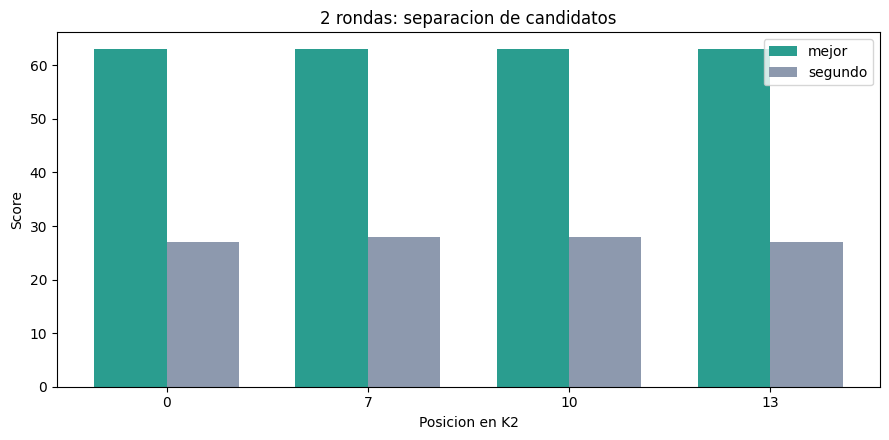

In [ ]:
x = range(len(results_2r))
width = 0.36
plt.figure(figsize=(9, 4.5))
plt.bar([v - width / 2 for v in x], results_2r["mejor score"], width, label="mejor", color="#2A9D8F")
plt.bar([v + width / 2 for v in x], results_2r["segundo score"], width, label="segundo", color="#8D99AE")
plt.xticks(list(x), results_2r["posicion"].astype(str))
plt.title("2 rondas: separacion de candidatos")
plt.xlabel("Posicion en K2")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

## Verificacion de pares utiles en 2 rondas

La clave real se usa solo para verificar la frecuencia observada.

In [ ]:
true_bytes_2r = cipher_2r._int_to_state(last_key_2r)
right_pairs_2r = 0
for c, c_prime in pairs_2r:
    pre_shift_a = [0] * cipher_2r.block_bytes
    pre_shift_b = [0] * cipher_2r.block_bytes
    for output_position, origin in enumerate(origins_2r):
        pre_shift_a[origin] = INV_S_BOX[c[output_position] ^ true_bytes_2r[output_position]]
        pre_shift_b[origin] = INV_S_BOX[c_prime[output_position] ^ true_bytes_2r[output_position]]
    observed = cipher_2r._state_to_int([a ^ b for a, b in zip(pre_shift_a, pre_shift_b)])
    right_pairs_2r += observed == DELTA_U_2R

print(f"Pares utiles observados: {right_pairs_2r}")
print(f"Pares utiles esperados: {N_PAIRS_2R * PROBABILITY_2R:.2f}")

Pares utiles observados: 63
Pares utiles esperados: 64.00


# Caso 2: AES-128 reducido a 3 rondas

Se usa la trayectoria original. Para alcanzar la entrada de la tercera ronda se necesita el prefijo de dos rondas:

$$P_{\mathrm{prefijo}}=2^{-30}.$$

Con $2^{16}$ pares se esperan solamente $2^{-14}\approx0.000061$ pares utiles.

In [ ]:
DELTA_P_3R = int(characteristic["initial_difference"], 16)
DELTA_U_3R = int(round_records[-1]["input_difference"], 16)
PROBABILITY_3R_PREFIX = math.prod(float(item["probability"]) for item in round_records[:-1])
N_PAIRS_3R = 1 << 16

cipher_3r = ReducedAES(rounds=3, block_bits=BLOCK_BITS, key_bits=KEY_BITS)
round_keys_3r = cipher_3r.expand_key_from_hex(MASTER_KEY_HEX)
last_key_3r = round_keys_3r[-1]

pairs_3r = generate_ciphertext_pairs(cipher_3r, round_keys_3r, DELTA_P_3R, N_PAIRS_3R, SEED)
rankings_3r, delta_bytes_3r, origins_3r, active_3r = rank_key_bytes(cipher_3r, pairs_3r, DELTA_U_3R)
results_3r = summarize_rankings(cipher_3r, last_key_3r, rankings_3r)

print(f"Delta P: 0x{DELTA_P_3R:032X}")
print(f"Delta U: 0x{DELTA_U_3R:032X}")
print(f"Pares: {N_PAIRS_3R:,}")
print(f"Pares utiles esperados: {N_PAIRS_3R * PROBABILITY_3R_PREFIX:.8f}")
print(f"Pares para un acierto esperado: {math.ceil(1 / PROBABILITY_3R_PREFIX):,}")
results_3r

Delta P: 0xB30000000058000000004500000000F7
Delta U: 0x3E1F1F21000000000000000000000000
Pares: 65,536
Pares utiles esperados: 0.00006104
Pares para un acierto esperado: 1,073,741,824


,posicion,mejor candidato,byte real,mejor score,segundo score,margen,rango real,correcto
0,0,0x7E,0xB6,315,297,18,61,False
1,7,0x2D,0xBF,300,298,2,81,False
2,10,0xC8,0x0C,299,291,8,64,False
3,13,0x0E,0x69,311,303,8,79,False


## Ranking de 3 rondas

Los bytes reales no ocupan el primer lugar porque la muestra no contiene suficientes pares correctos.

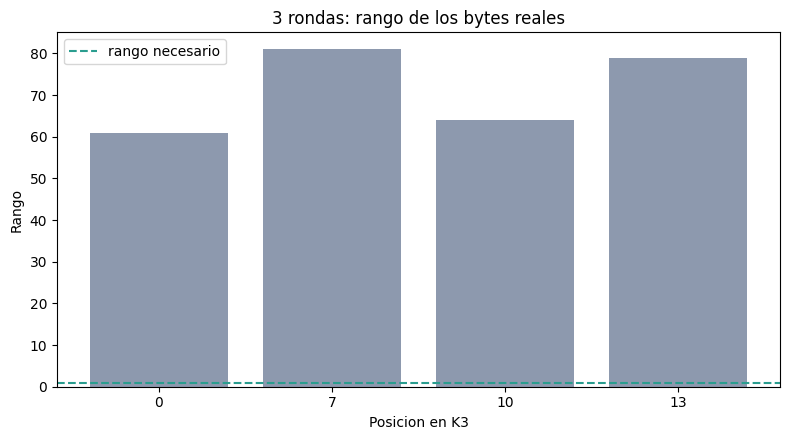

In [ ]:
plt.figure(figsize=(8, 4.5))
plt.bar(results_3r["posicion"].astype(str), results_3r["rango real"], color="#8D99AE")
plt.axhline(1, color="#2A9D8F", linestyle="--", label="rango necesario")
plt.title("3 rondas: rango de los bytes reales")
plt.xlabel("Posicion en K3")
plt.ylabel("Rango")
plt.legend()
plt.tight_layout()
plt.show()

# Comparacion final

In [ ]:
comparison_df = pd.DataFrame([
    {
        "caso": "2 rondas",
        "probabilidad hasta Delta U": PROBABILITY_2R,
        "peso": -math.log2(PROBABILITY_2R),
        "pares usados": N_PAIRS_2R,
        "pares utiles esperados": N_PAIRS_2R * PROBABILITY_2R,
        "bytes recuperados": int(results_2r["correcto"].sum()),
    },
    {
        "caso": "3 rondas",
        "probabilidad hasta Delta U": PROBABILITY_3R_PREFIX,
        "peso": -math.log2(PROBABILITY_3R_PREFIX),
        "pares usados": N_PAIRS_3R,
        "pares utiles esperados": N_PAIRS_3R * PROBABILITY_3R_PREFIX,
        "bytes recuperados": int(results_3r["correcto"].sum()),
    },
])
comparison_df

,caso,probabilidad hasta Delta U,peso,pares usados,pares utiles esperados,bytes recuperados
0,2 rondas,1.562500e-02,6.0,4096,64.000000,4
1,3 rondas,9.313226e-10,30.0,65536,0.000061,0


## Conclusion

- **2 rondas:** 4096 pares reales producen aproximadamente 64 pares utiles y recuperan los cuatro bytes activos.
- **3 rondas:** $2^{16}$ pares producen una esperanza de $0.000061$ pares utiles; los rankings quedan dominados por ruido.

El procedimiento es el mismo. La diferencia entre ambos resultados proviene de la probabilidad del prefijo diferencial.